# 3 · Sound Classification on sub classes

KNN classification on the BSD10k **subset** created in notebook 1.
Compares MFCC, FSD-SINet, and CLAP embeddings, then digs into misclassifications by listening.
Finally, it uses the Freesound API to download some sounds and look at the classification over those.

The classifiers here work on all the different classes. The results are compared also with the previous study, where only top classes where considered

## 0 · Setup

In [1]:
import os, sys, json, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, IFrame

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedShuffleSplit

# ── Paths (same root as notebook 1) ──────────────────────────────────────────
METADATA_FOLDER  = '../metadata'
EMBEDDINGS_FOLDER = '../embeddings'
SUBSET_CSV       = '../metadata/subset_metadata.csv'
# ─────────────────────────────────────────────────────────────────────────────

def show_sound_player(sound_id):
    display(IFrame(f'https://freesound.org/embed/sound/iframe/{sound_id}/simple/medium/', width=596, height=100))


## 1 · Load subset metadata

In [2]:
subset_df = pd.read_csv(SUBSET_CSV)
print(f'Loaded {len(subset_df)} sounds, {subset_df["class"].nunique()} classes')
display(subset_df.groupby(['class', 'class_name']).size().rename('count'))


Loaded 7205 sounds, 15 classes


class  class_name        
fx-a   Sound effects          168
fx-n   Sound effects          659
fx-o   Sound effects         1203
fx-v   Sound effects          199
is-k   Instrument samples     111
is-s   Instrument samples     529
is-w   Instrument samples     552
m-m    Music                  291
m-si   Music                  655
m-sp   Music                  689
sp-c   Speech                  96
sp-s   Speech                 801
ss-i   Soundscapes            178
ss-n   Soundscapes            389
ss-u   Soundscapes            685
Name: count, dtype: int64

## 2 · Train / test split

BSD10k (v1.0) does not ship with a predefined split column.
We create a **stratified 80/20 split** so every class is proportionally represented in both sets.
The split is fixed with `random_state=42` for reproducibility.


In [3]:
train_idx = subset_df.index[subset_df['set'] == 'train'].tolist()
test_idx = subset_df.index[subset_df['set'] == 'test'].tolist()

train_df = subset_df.iloc[train_idx].copy()
test_df  = subset_df.iloc[test_idx].copy()

print(f'Train: {len(train_df)} sounds   Test: {len(test_df)} sounds')
print()
split_summary = pd.DataFrame({
    'train': train_df['class'].value_counts(),
    'test':  test_df['class'].value_counts(),
}).fillna(0).astype(int)
display(split_summary)


Train: 6605 sounds   Test: 600 sounds



,train,test
class,,
fx-a,128,40
fx-n,619,40
fx-o,1163,40
fx-v,159,40
is-k,71,40
is-s,489,40
is-w,512,40
m-m,251,40
m-si,615,40


## 3 · Load embeddings

In [4]:
def load_embeddings(df, method, embeddings_folder):
    """Load pre-computed .npy embeddings for every sound in df."""
    folder = os.path.join(embeddings_folder, method)
    paths  = [os.path.join(folder, f'{sid}.npy') for sid in df['sound_id']]

    # Skip sounds whose embedding file is missing (e.g. extraction errors)
    valid_mask = np.array([os.path.exists(p) for p in paths])
    if valid_mask.sum() < len(df):
        print(f'  [{method}] {(~valid_mask).sum()} files missing — skipping those sounds')

    example = np.load(paths[valid_mask.argmax()])
    X = np.zeros((len(paths), len(example)))
    for i, (p, ok) in enumerate(zip(paths, valid_mask)):
        if ok:
            X[i] = np.load(p)
    return X, valid_mask


EMBEDDING_TYPES = [d for d in ['mfcc', 'fsdsinet', 'clap', 'fs_similarity']
                   if os.path.isdir(os.path.join(EMBEDDINGS_FOLDER, d))]
print(f'Available embedding types: {EMBEDDING_TYPES}')

X_train_all, X_test_all = {}, {}
for method in EMBEDDING_TYPES:
    X_tr, mask_tr = load_embeddings(train_df, method, EMBEDDINGS_FOLDER)
    X_te, mask_te = load_embeddings(test_df,  method, EMBEDDINGS_FOLDER)
    X_train_all[method] = X_tr
    X_test_all[method]  = X_te
    print(f'  {method}: train {X_tr.shape}  test {X_te.shape}')

y_train = train_df['class'].values
y_test  = test_df['class'].values


Available embedding types: ['mfcc', 'fsdsinet', 'clap', 'fs_similarity']
  mfcc: train (6605, 13)  test (600, 13)
  fsdsinet: train (6605, 512)  test (600, 512)
  clap: train (6605, 512)  test (600, 512)
  fs_similarity: train (6605, 100)  test (600, 100)


## 4 · Compare embedding types (KNN, k=5)

In [5]:
results = {}
print(f'{'Embedding':<15}  {'Accuracy':>10}  {'Random baseline':>16}')
print('-' * 45)

for method in EMBEDDING_TYPES:
    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(X_train_all[method])
    X_te    = scaler.transform(X_test_all[method])

    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)

    acc      = accuracy_score(y_test, y_pred)
    baseline = 1.0 / len(set(y_train))
    results[method] = dict(acc=acc, baseline=baseline, y_pred=y_pred, clf=clf, scaler=scaler)

    print(f'{method:<15}  {acc:>10.3f}  {baseline:>16.3f}')


Embedding          Accuracy   Random baseline
---------------------------------------------
mfcc                  0.313             0.067
fsdsinet              0.590             0.067
clap                  0.762             0.067
fs_similarity         0.475             0.067


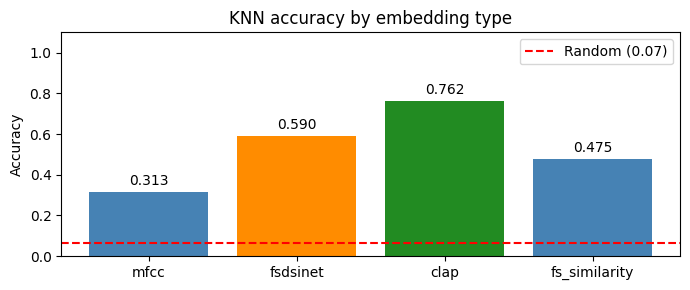

In [6]:
# Bar chart comparison
methods = list(results.keys())
accs    = [results[m]['acc'] for m in methods]
baseline = results[methods[0]]['baseline']

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(methods, accs, color=['steelblue', 'darkorange', 'forestgreen'][:len(methods)])
ax.axhline(baseline, color='red', linestyle='--', label=f'Random ({baseline:.2f})')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('KNN accuracy by embedding type')
ax.legend()
plt.tight_layout()
plt.show()


## 5 · Deep dive: best embedding and confusion matrices

Classification report for the best performing embedding and confusion matrices.


In [7]:
best = max(results, key=lambda m: results[m]['acc'])
print(f'Best embedding: {best}  (accuracy = {results[best]["acc"]:.3f})')
print()
print(classification_report(y_test, results[best]['y_pred']))


Best embedding: clap  (accuracy = 0.762)

              precision    recall  f1-score   support

        fx-a       0.79      0.55      0.65        40
        fx-n       0.85      0.97      0.91        40
        fx-o       0.80      0.97      0.88        40
        fx-v       0.96      0.57      0.72        40
        is-k       0.97      0.88      0.92        40
        is-s       0.93      0.93      0.93        40
        is-w       0.93      0.97      0.95        40
         m-m       0.88      0.55      0.68        40
        m-si       0.77      0.93      0.84        40
        m-sp       0.80      0.93      0.86        40
        sp-c       0.88      0.35      0.50        40
        sp-s       0.77      0.93      0.84        40
        ss-i       0.50      0.33      0.39        40
        ss-n       0.68      0.80      0.74        40
        ss-u       0.39      0.78      0.52        40

    accuracy                           0.76       600
   macro avg       0.79      0.76     

Confusion Matrices across all embeddings:


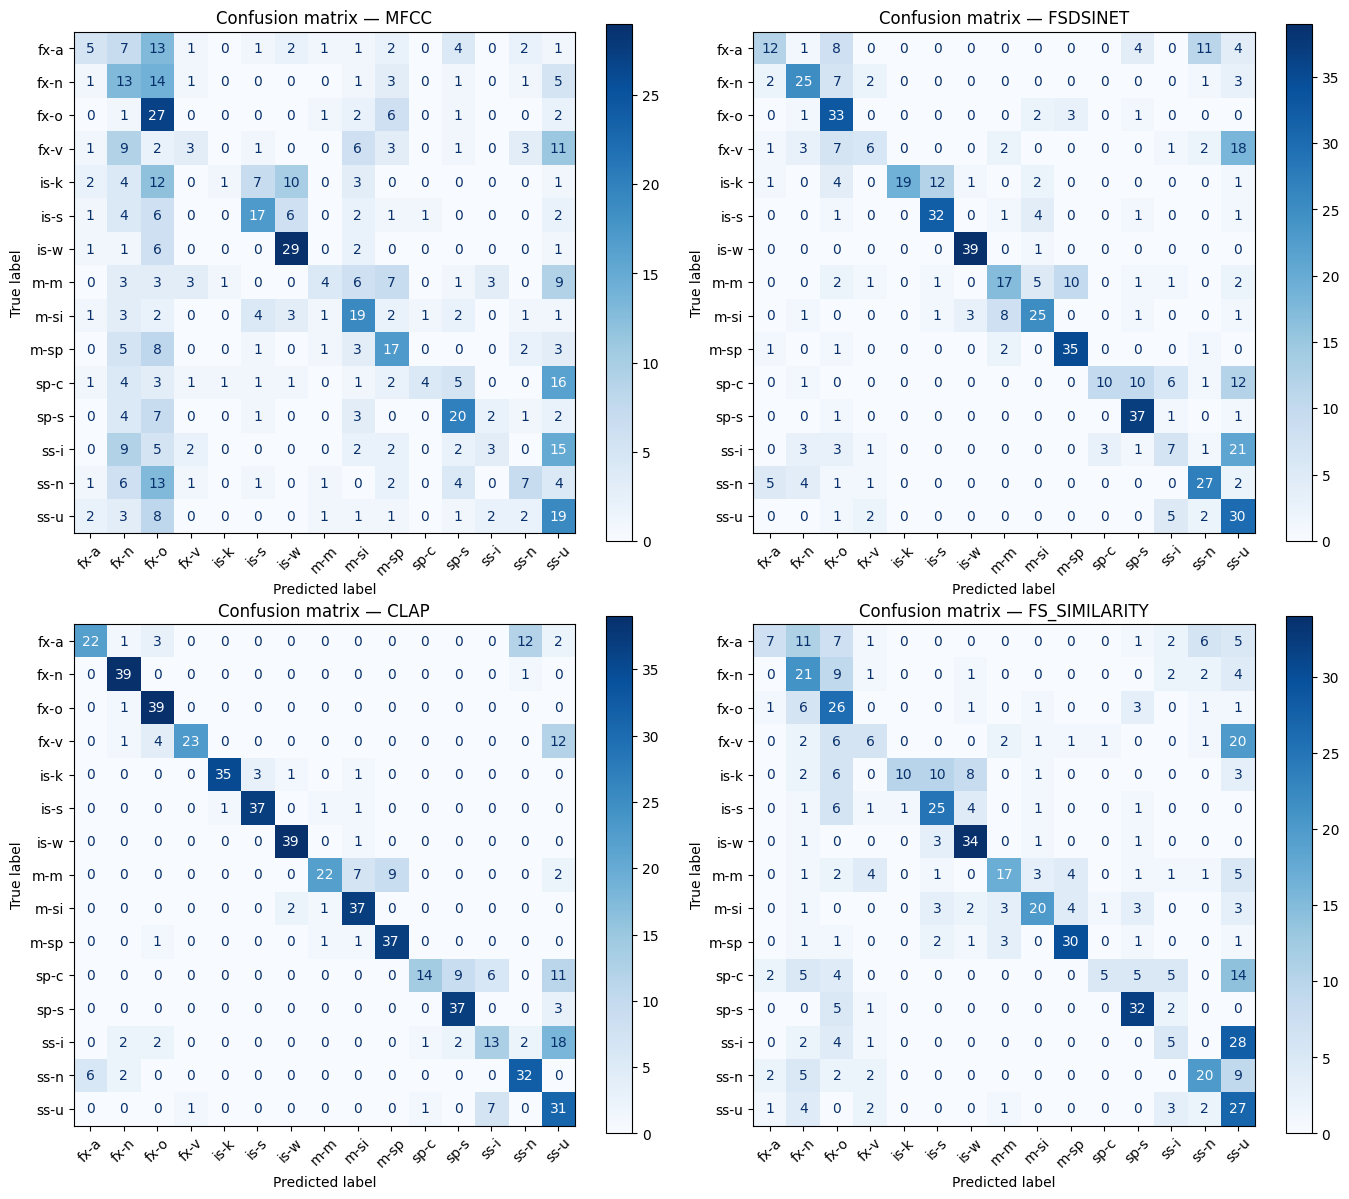

In [8]:
import math

# Determine grid size based on the number of embeddings
num_embeddings = len(EMBEDDING_TYPES)
cols = 2
rows = math.ceil(num_embeddings / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
axes = axes.flatten()

print("Confusion Matrices across all embeddings:")

for i, method in enumerate(EMBEDDING_TYPES):
    clf = results[method]['clf']
    y_pred = results[method]['y_pred']
    
    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    disp = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)
    
    disp.plot(ax=axes[i], xticks_rotation=45, cmap='Blues')
    axes[i].set_title(f'Confusion matrix — {method.upper()}')

# Hide any empty subplots if we have an odd number of embeddings
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [9]:
hierarchy_df = pd.read_csv('../metadata/BST_description.csv')
# Create a lookup dictionary: {ClassKey: TopLevel}
hierarchy_map = dict(zip(hierarchy_df['ClassKey'], hierarchy_df['TopLevel']))

Confusion Matrices (Top-Level Categories):


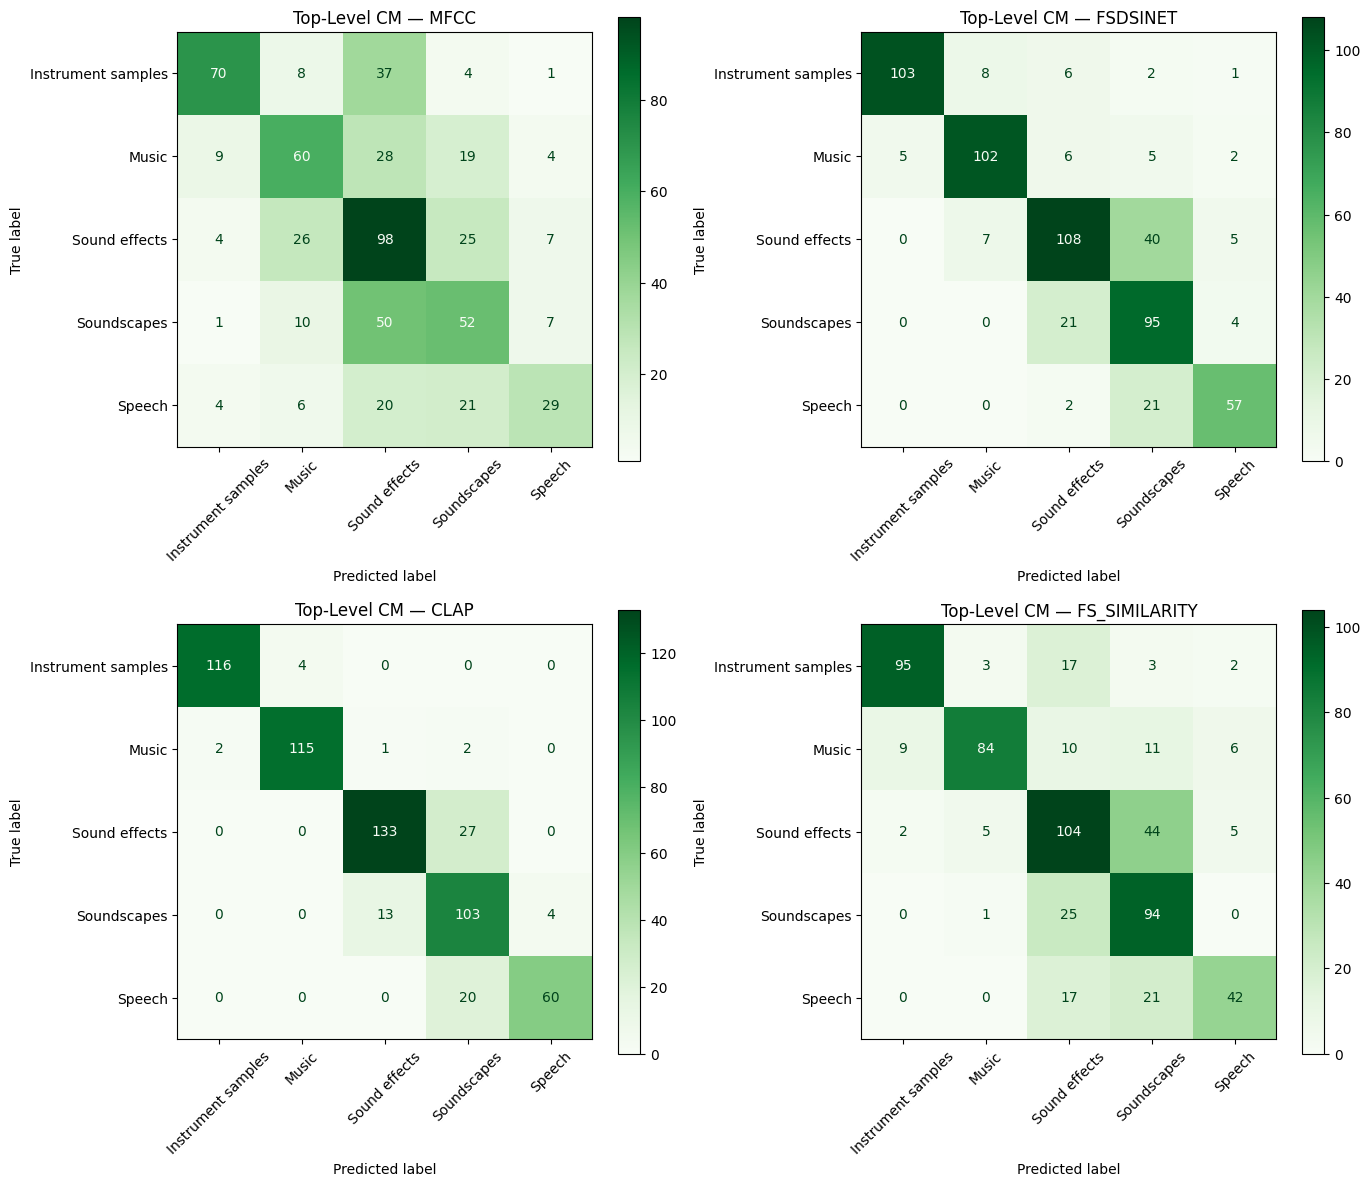

In [10]:
fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
axes = axes.flatten()

print("Confusion Matrices (Top-Level Categories):")

for i, method in enumerate(EMBEDDING_TYPES):
    # Get the original predictions
    y_pred_sub = results[method]['y_pred']
    
    # Map both y_test and y_pred_sub to their TopLevel equivalents
    y_test_top = [hierarchy_map.get(label, 'Unknown') for label in y_test]
    y_pred_top = [hierarchy_map.get(label, 'Unknown') for label in y_pred_sub]
    
    # Get unique top-level categories present in the data to ensure correct ordering
    unique_top_labels = sorted(list(set(y_test_top) | set(y_pred_top)))
    
    # Generate and plot confusion matrix
    cm = confusion_matrix(y_test_top, y_pred_top, labels=unique_top_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=unique_top_labels)
    
    disp.plot(ax=axes[i], xticks_rotation=45, cmap='Greens') # Changed to Greens for distinction
    axes[i].set_title(f'Top-Level CM — {method.upper()}')

# Clean up empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6 · Per-class F1 across all embeddings

,mfcc,fsdsinet,clap,fs_similarity
fx-a,0.179,0.387,0.647,0.264
fx-n,0.224,0.633,0.907,0.408
fx-o,0.320,0.606,0.876,0.441
fx-v,0.115,0.226,0.719,0.203
is-k,0.047,0.644,0.921,0.392
is-s,0.459,0.744,0.925,0.595
is-w,0.637,0.940,0.951,0.747
m-m,0.160,0.486,0.677,0.515
m-si,0.413,0.633,0.841,0.588
m-sp,0.386,0.795,0.860,0.759


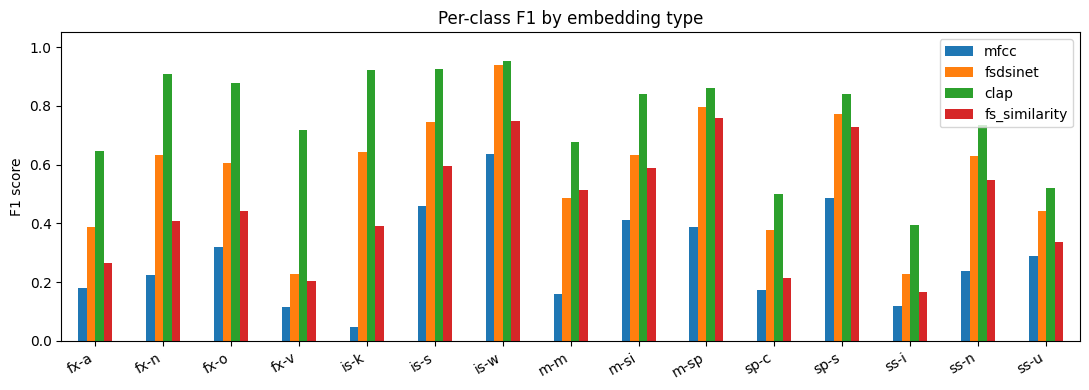

In [11]:
from sklearn.metrics import classification_report

classes = sorted(set(y_test))
f1_data = {}
for method in EMBEDDING_TYPES:
    report = classification_report(y_test, results[method]['y_pred'], output_dict=True)
    f1_data[method] = {cls: report.get(cls, {}).get('f1-score', 0.0) for cls in classes}

f1_df = pd.DataFrame(f1_data, index=classes)
display(f1_df.round(3))

f1_df.plot(kind='bar', figsize=(11, 4), ylim=(0, 1.05))
plt.ylabel('F1 score')
plt.title('Per-class F1 by embedding type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 7 · Misclassification analysis

Listen to wrongly classified sounds and reason about *why* the model was confused.
Focus on:
- Is the ground-truth label arguably correct for this specific sound, or is it borderline?
- Does the acoustic content sound more like the predicted class?
- Does a different embedding type get it right?


In [12]:
from collections import Counter

y_pred_best = results[best]['y_pred']
misclassified = [
    {'sound_id': test_df.iloc[i]['sound_id'],
     'title':    test_df.iloc[i]['title'],
     'gt':       y_test[i],
     'pred':     y_pred_best[i]}
    for i in np.where(y_test != y_pred_best)[0]
]

print(f'Total misclassifications: {len(misclassified)} / {len(y_test)}')
print()
pairs = Counter((m['gt'], m['pred']) for m in misclassified)
print(f'{'Ground truth':<30}  {'Predicted':<30}  {'Count':>5}')
print('-' * 70)
for (gt, pred), count in pairs.most_common(15):
    print(f'{gt:<30}  {pred:<30}  {count:>5}')


Total misclassifications: 143 / 600

Ground truth                    Predicted                       Count
----------------------------------------------------------------------
ss-i                            ss-u                               18
fx-a                            ss-n                               12
fx-v                            ss-u                               12
sp-c                            ss-u                               11
m-m                             m-sp                                9
sp-c                            sp-s                                9
m-m                             m-si                                7
ss-u                            ss-i                                7
ss-n                            fx-a                                6
sp-c                            ss-i                                6
fx-v                            fx-o                                4
is-k                            is-s                

In [13]:
# Listen to 5 random misclassifications
for m in random.sample(misclassified, min(5, len(misclassified))):
    print('─' * 60)
    print(f"Title:        {m['title']}")
    print(f"Ground truth: {m['gt']}")
    print(f"Predicted:    {m['pred']}")
    show_sound_player(m['sound_id'])


────────────────────────────────────────────────────────────
Title:        Cheers!.wav
Ground truth: sp-c
Predicted:    sp-s


────────────────────────────────────────────────────────────
Title:        azraInterestedFrustrated.WAV
Ground truth: sp-c
Predicted:    ss-i


────────────────────────────────────────────────────────────
Title:        TL LEG WARMER FOR ARM.wav
Ground truth: sp-c
Predicted:    sp-s


────────────────────────────────────────────────────────────
Title:        150 clarinet loop 2.wav
Ground truth: m-si
Predicted:    is-w


────────────────────────────────────────────────────────────
Title:        electric powered boat 121230_02.wav
Ground truth: fx-v
Predicted:    fx-n


## 8 Freesound API sounds classification


I have tried using the given code in the notebooks, but I actually ended up with several bugs that I was not able to manage to overcome. I opted for using the transformers library and the ClapModel in it in order to extract the embeddings from the downloaded sounds. I was scared that the checkpoint might not be exactly the same one, or even the exact architecture as the embeddings given were extracted with. However, I ended up with classifications with the pre-fitted k-NN that were arguably correct, so I thought that it was not that big of a deal.

In [14]:
import requests


# ── Freesound API Setup ──────────────────────────────────────────────────────
FREESOUND_API_KEY = "PyvBW7gd49TfWXFUKbXGDTN6uyy8MFaXYnCNEmM2" 

# =============================================================================
# Test Query Matrix (In-Distribution & Out-of-Distribution)
# =============================================================================
TEST_SUITE = {
    "In-Distribution (Expected Environments/Animals/Music)": [
        "dog bark park",
        "thunderstorm rain",
        "acoustic guitar chord",
        "cat meow purr",
        "footsteps concrete"
    ],
    "Out-of-Distribution (OOD - Synthetic/Glitch/Industrial)": [
        "sine wave 440hz",          # Pure mathematical tone
        "telephone dial tone",       # Continuous uniform telecommunication signal
        "white noise static",        # Stochastic uniform signal
        "digital glitch error",      # Non-organic high-frequency burst
        "geiger counter radiation",  # Random, sparse impulse clicks
        "hydraulic piston machine"   # Heavy mechanical cyclic pattern
    ]
}

def download_freesound_preview(query, api_key, max_duration=30.0):
    """
    Searches Freesound, enforcing a strict duration limit using API-side filters,
    and downloads the HQ MP3 preview of the top result.
    """
    url = "https://freesound.org/apiv2/search/text/"
    
    # Using a params dict ensures characters like '[' or ' ' are safely encoded
    params = {
        "query": query,
        "token": api_key,
        "fields": "id,name,previews,duration",
        # API filter constraints: duration from 0.0 up to max_duration seconds
        "filter": f"duration:[0.0 TO {max_duration}]"
    }
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()
    except Exception as e:
        print(f"API Error for query '{query}': {e}")
        return None, None
    
    if 'results' not in data or len(data['results']) == 0:
        print(f"⚠️ No sounds found for query: '{query}' within {max_duration} seconds.")
        return None, None
        
    top_result = data['results'][0]
    sound_id = top_result['id']
    sound_name = top_result['name']
    sound_duration = top_result.get('duration', 'unknown')
    preview_url = top_result['previews']['preview-hq-mp3']
    
    print(f"✅ Found: '{sound_name}' | ID: {sound_id} | Duration: {sound_duration}s")
    
    # Optional wrapper fallback if your notebook environment uses this
    if 'show_sound_player' in globals():
        try:
            show_sound_player(sound_id)
        except Exception:
            pass
    
    # Local download stream
    audio_path = f"temp_{sound_id}.mp3"
    try:
        with requests.get(preview_url, stream=True) as r:
            r.raise_for_status()
            with open(audio_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        return audio_path, sound_name
    except Exception as e:
        print(f"Failed downloading binary data for ID {sound_id}: {e}")
        return None, None

# =============================================================================
# Automated Batch Evaluation Loop
# =============================================================================
# Dictionary to store downloadable file references for downstream processing
downloaded_manifest = {}

print("--- Starting Controlled Freesound Sample Retrieval (Max 30s) ---\n")

for category, queries in TEST_SUITE.items():
    print(f"\n==========================================")
    print(f"📂 Category: {category}")
    print(f"==========================================")
    
    downloaded_manifest[category] = []
    
    for q in queries:
        print(f"\n🔍 Querying: '{q}'...")
        file_path, actual_title = download_freesound_preview(q, FREESOUND_API_KEY, max_duration=30.0)
        
        if file_path and os.path.exists(file_path):
            downloaded_manifest[category].append({
                "query": q,
                "title": actual_title,
                "file_path": file_path
            })

print("\n--- Download complete. Ready for feature extraction pipeline ---")

--- Starting Controlled Freesound Sample Retrieval (Max 30s) ---


📂 Category: In-Distribution (Expected Environments/Animals/Music)

🔍 Querying: 'dog bark park'...
✅ Found: 'dog barking in the park at spring time' | ID: 654723 | Duration: 15.6706s



🔍 Querying: 'thunderstorm rain'...
✅ Found: 'Thunderstorm strong Tallinn tascam DR 44W.wav' | ID: 349487 | Duration: 24.1488s



🔍 Querying: 'acoustic guitar chord'...
✅ Found: 'Acoustic Guitar D Major Chord Short' | ID: 315705 | Duration: 0.662041s



🔍 Querying: 'cat meow purr'...
✅ Found: 'young female cat raspy purr to meow' | ID: 766076 | Duration: 7.77467s



🔍 Querying: 'footsteps concrete'...
✅ Found: 'FEETHmn-Samsung Galaxy Smartphone, MCU_Footsteps On Concrete_Nicholas Judy_TDC' | ID: 807868 | Duration: 7.29116s


...


🔍 Querying: 'white noise static'...
✅ Found: 'Short Wave Radio Noise 1' | ID: 257880 | Duration: 12.0989s



🔍 Querying: 'digital glitch error'...
✅ Found: 'GlitchError' | ID: 718742 | Duration: 0.427007s



🔍 Querying: 'geiger counter radiation'...
✅ Found: 'Geiger Counter Hotspot (Uneven)' | ID: 555933 | Duration: 21.44s



🔍 Querying: 'hydraulic piston machine'...
✅ Found: 'Hydraulic, Office Chair.wav' | ID: 432253 | Duration: 17.3046s



--- Download complete. Ready for feature extraction pipeline ---


In [15]:
import os
import csv
import torch
import librosa
import numpy as np
from transformers import AutoProcessor, ClapModel

# =============================================================================
# 1. Map Taxonomy CSV (SubClass Key -> TopLevel Class)
# =============================================================================
CLASS_CSV_PATH = SUBSET_CSV  # Update with your actual CSV path
subclass_to_toplevel = {}

print("Parsing taxonomy CSV file...")
with open(CLASS_CSV_PATH, mode='r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    headers = {k.lower().strip(): k for k in reader.fieldnames} if reader.fieldnames else {}
    
    key_col = headers["class"]
    top_col = headers["class_name"]

    for row in reader:
        sub_key = row[key_col].strip() if key_col else ""
        top_lvl = row[top_col].strip() if top_col else ""
        if sub_key:
            subclass_to_toplevel[sub_key] = top_lvl

# =============================================================================
# 2. Load Native LAION-CLAP via Transformers
# =============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "laion/clap-htsat-fused" 

print(f"Loading native LAION-CLAP model onto {device}...")
model = ClapModel.from_pretrained(model_name).to(device)
processor = AutoProcessor.from_pretrained(model_name)
model.eval()

# Reference your pre-fitted kNN model from your session results
fitted_knn = results['clap']['clf'] 

# =============================================================================
# 3. Predict via Pre-Fitted k-NN Proximity
# =============================================================================
print("\n--- Starting Corrected k-NN Proximity Inference Loop ---")

for category, samples in downloaded_manifest.items():
    print(f"\n==============================================================")
    print(f"📂 Evaluating Dataset Slice via k-NN: {category}")
    print(f"==============================================================")
    
    for sample in samples:
        q = sample.get("query", "Unknown")
        title = sample.get("title", "Unknown")
        file_path = sample.get("file_path", "")
        
        if not file_path or not os.path.exists(file_path):
            continue
            
        try:
            # 1. Load audio at 48000Hz
            audio_array, _ = librosa.load(file_path, sr=48000)
            
            # 2. Extract Raw LAION-CLAP Audio Feature Matrix
            inputs = processor(audio=audio_array, sampling_rate=48000, return_tensors="pt").to(device)
            with torch.no_grad():
                # Call audio-only extraction feature route
                audio_outputs = model.get_audio_features(**inputs)
                
                # --- DEFENSIVE TENSOR UNPACKING ---
                if isinstance(audio_outputs, torch.Tensor):
                    audio_embeddings = audio_outputs
                elif hasattr(audio_outputs, "pooler_output") and audio_outputs.pooler_output is not None:
                    audio_embeddings = audio_outputs.pooler_output
                elif hasattr(audio_outputs, "last_hidden_state") and audio_outputs.last_hidden_state is not None:
                    audio_embeddings = audio_outputs.last_hidden_state.mean(dim=1)
                elif isinstance(audio_outputs, dict):
                    audio_embeddings = audio_outputs.get("pooler_output", list(audio_outputs.values())[0])
                else:
                    audio_embeddings = audio_outputs[0]

                # In some older library versions, get_audio_features leaves out the projection layer.
                # If the vector dimension isn't 512, manually project it to match CLAP's latent space.
                if hasattr(model, "audio_projection") and audio_embeddings.shape[-1] != 512:
                    audio_embeddings = model.audio_projection(audio_embeddings)
                
                # Normalize vector to calculate precise metric alignment
                audio_embeddings = audio_embeddings / audio_embeddings.norm(dim=-1, keepdim=True)
                
            raw_vector_np = audio_embeddings.cpu().numpy()  # Shape: (1, 512)
            
            # 3. Predict using the surrounding space vectors in your pre-fitted k-NN model
            predicted_subclass = fitted_knn.predict(raw_vector_np)[0]
            
            # 4. Resolve the winner back to its TopLevel parent via CSV dictionary
            associated_top_level = subclass_to_toplevel.get(predicted_subclass, "UNKNOWN TOPLEVEL")
            
            # Get neighborhood voting confidence if supported by your classifier instance
            confidence_str = ""
            if hasattr(fitted_knn, "predict_proba"):
                probs = fitted_knn.predict_proba(raw_vector_np)[0]
                confidence_str = f" | Neighborhood Vote Strength: {np.max(probs):.4f}"

            print(f"\n🔍 Freesound Target Search: '{q}'")
            print(f"   🎵 Asset Track Name   : {title[:60]}...")
            print(f"   🎯 Winner SUB-CLASS   : {predicted_subclass.upper()} (From k-NN surroundings)")
            print(f"   🏆 Resolved TOP-LEVEL : {associated_top_level.upper()}{confidence_str}")
            
        except Exception as e:
            print(f"❌ Failed to process point via k-NN classification: {e}")

/home/frederic/Documents/UPF/semester3/advanced/block2_assignment/sound-classification-repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Parsing taxonomy CSV file...
Loading native LAION-CLAP model onto cuda...


Loading weights: 100%|██████████| 477/477 [00:00<00:00, 5802.31it/s]



--- Starting Corrected k-NN Proximity Inference Loop ---

📂 Evaluating Dataset Slice via k-NN: In-Distribution (Expected Environments/Animals/Music)

🔍 Freesound Target Search: 'dog bark park'
   🎵 Asset Track Name   : dog barking in the park at spring time...
   🎯 Winner SUB-CLASS   : FX-A (From k-NN surroundings)
   🏆 Resolved TOP-LEVEL : SOUND EFFECTS | Neighborhood Vote Strength: 0.4000

🔍 Freesound Target Search: 'thunderstorm rain'
   🎵 Asset Track Name   : Thunderstorm strong Tallinn tascam DR 44W.wav...
   🎯 Winner SUB-CLASS   : FX-N (From k-NN surroundings)
   🏆 Resolved TOP-LEVEL : SOUND EFFECTS | Neighborhood Vote Strength: 0.6000

🔍 Freesound Target Search: 'acoustic guitar chord'
   🎵 Asset Track Name   : Acoustic Guitar D Major Chord Short...
   🎯 Winner SUB-CLASS   : FX-O (From k-NN surroundings)
   🏆 Resolved TOP-LEVEL : SOUND EFFECTS | Neighborhood Vote Strength: 0.4000

🔍 Freesound Target Search: 'cat meow purr'
   🎵 Asset Track Name   : young female cat raspy purr t

The results are in general very biased towards the Sound Effects class, but this can be expected as over 2k samples belong to that top level class. For the first two, dog barking and rain, even the subclass is correct, (animal, and natural elements and explosions). Of course, one could argue that rain is not really a natural element or explosion given that the class Soundscape Nature exists, however, if listening to the sample, we can see that even explosion is not that crazy of a classification. The acoustic guitar chord has been classified as Sound Effect object, which is not entirely wrong and probably the most accurate one inside Sound Effects, but most probably should have gone in Instrument Samples Strings. The meow purr has been classified as Soundscape Nature. Listening to the audio, why not. There is only one meow, the rest is quite silent (of course, FX-Animals would have been more accurate).

For a little bit more out of domain, the concrete footsteps has been classified as FX-Object, which makes sense maybe having discarded the FX-Human Sounds from the inital BSD10k. The sine wave, the geiger counter, the white noise and the digital glitch error have all been classified as FX-Animal, which is actually quite weird. Listening and knowing the geiger counter radiation sounds, maybe it can make sense (a cricket, or some sort of frog with very repeated sounds... it could make, to some extent, sense). However, we can see that keeping out all these synthetic sounds by removing them from the data has made almost impossible to classify them. However, they all have the lowest neighborhood voting strenght, meaning they are the one's that the k-NN is less certain of. The hidraulic piston has been classified as an FX-Object, which is actually good enough knowing that no machines, other engines and other mechanisms were present aside from cars and house appliances in the taken subset. Finally, the telephone dial tone has been assigned to FX-Natural Element and Explosions, which for me is not actually accurate, as I think objects and house appliances would have probably made much more sense, or maybe FX-Electronic if I would have kept it.